In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os

In [33]:
classes = pd.read_csv("/Users/zeus/Desktop/graphsield/data/raw/elliptic_txs_classes.csv")
edges = pd.read_csv("/Users/zeus/Desktop/graphsield/data/raw/elliptic_txs_edgelist.csv")
features = pd.read_csv("/Users/zeus/Desktop/graphsield/data/raw/elliptic_txs_features.csv", header=None)

In [34]:
print("The shape of classes" , classes.shape)
print("The shape of edges" , edges.shape)
print("The shape of features" , features.shape)

The shape of classes (203769, 2)
The shape of edges (234355, 2)
The shape of features (203769, 167)


In [35]:
def profile_dataframe(df, name):
	print(f"--- {name} ---")
	print("Shape:", df.shape)
	print("Columns:", df.columns.tolist())
	print("Data Types:\n", df.dtypes)
	print("Missing Values:\n", df.isnull().sum())
	print("Unique Values:\n", df.nunique())
	print("\nSample Data:\n", df.head(), "\n")

In [ ]:
profile_dataframe(classes, "Classes")
profile_dataframe(edges, "Edges")
profile_dataframe(features, "Features")

### Check Class Distrubtion

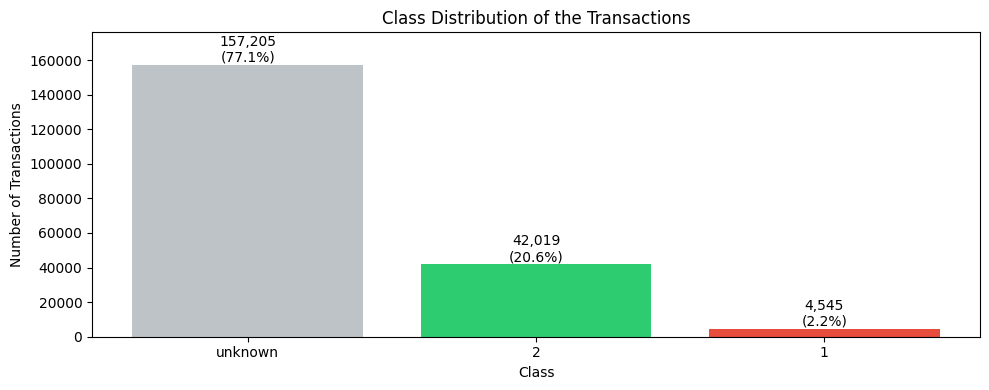

In [76]:
counts = classes['class'].value_counts()
total = counts.sum()
percentages = (counts / total * 100)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(counts.index, counts.values, color=['#bdc3c7', '#2ecc71', '#e74c3c'])

# Add percentage labels on top of each bar
for bar, pct, count in zip(bars, percentages.values, counts.values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_ylim(0, counts.max() * 1.12)
ax.set_xlabel('Class')
ax.set_ylabel('Number of Transactions')
ax.set_title('Class Distribution of the Transactions')

plt.tight_layout()
plt.savefig(FIGURES / 'class_distrubtion.png', dpi=150, bbox_inches='tight')
plt.show()

In [74]:
from pathlib import Path
FIGURES = Path('../figures')   # if notebook is in notebooks/ folder
FIGURES.mkdir(exist_ok=True)

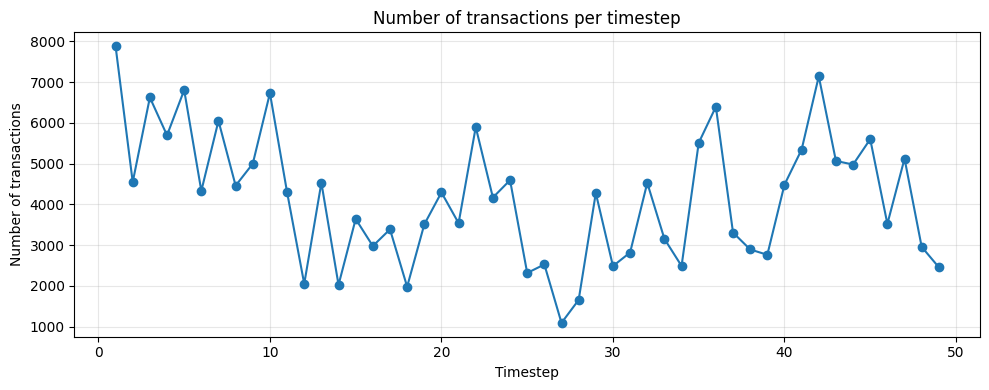

In [75]:
group_feature = features.groupby("timestep").count()

fig, ax = plt.subplots(figsize=(10, 4))
group_feature['txId'].plot(ax=ax, marker='o')
ax.set_title('Number of transactions per timestep')
ax.set_xlabel('Timestep')
ax.set_ylabel('Number of transactions')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'txns_per_timestep.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
features.columns = ['txId', 'timestep'] + [f'features_{i}' for i in range(1, 166)]
features.head()

,txId,timestep,features_1,features_2,features_3,features_4,features_5,features_6,features_7,features_8,...,features_156,features_157,features_158,features_159,features_160,features_161,features_162,features_163,features_164,features_165
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [52]:
df = features.merge(classes, on='txId', how='left')

In [53]:
df.head()

,txId,timestep,features_1,features_2,features_3,features_4,features_5,features_6,features_7,features_8,...,features_157,features_158,features_159,features_160,features_161,features_162,features_163,features_164,features_165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [62]:
label_map = {'1': 1, '2': 0, 'unknown': -1}
df['y'] = df['class'].map(label_map)

/var/folders/t2/_4gj35f939s126fp_hj7th040000gn/T/ipykernel_76587/3444947641.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['y'] = df['class'].map(label_map)


In [69]:
G = nx.DiGraph()

edge_tuples = list(zip(edges['txId1'].values, edges['txId2'].values))
G.add_edges_from(edge_tuples)

nx.set_node_attributes(G, dict(zip(df['txId'], df['timestep'])), 'timestep')
nx.set_node_attributes(G, dict(zip(df['txId'], df['y'])), 'label')

In [70]:
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")

# Pick any node and inspect it
sample_node = next(iter(G.nodes()))
print(f"Sample node: {sample_node}")
print(f"Attributes:  {G.nodes[sample_node]}")

Nodes: 203,769
Edges: 234,355
Sample node: 230425980
Attributes:  {'timestep': 1, 'label': -1}


Top 5 illicit nodes by degree:
  Node 30179316: 177 connections
  Node 269905668: 173 connections
  Node 96365231: 166 connections
  Node 99675435: 158 connections
  Node 355110272: 153 connections


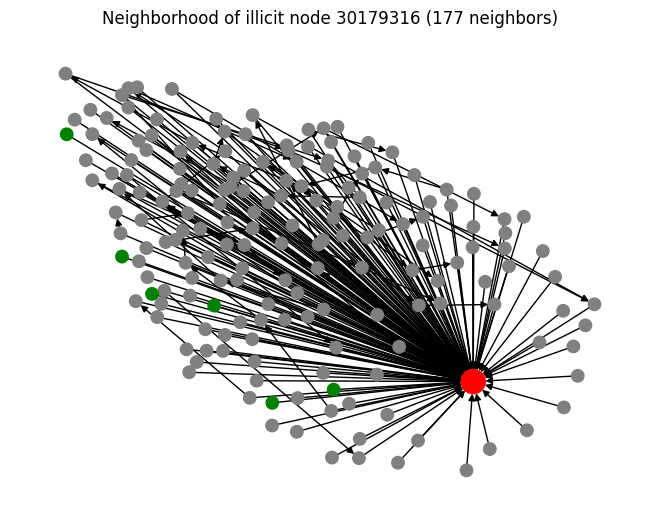

In [68]:
# Find all illicit nodes and sort by degree (number of connections)
illicit_nodes = [n for n, d in G.nodes(data=True) if d.get('label') == 1]
illicit_with_degree = [(n, G.degree(n)) for n in illicit_nodes]
illicit_with_degree.sort(key=lambda x: x[1], reverse=True)

print(f"Top 5 illicit nodes by degree:")
for n, deg in illicit_with_degree[:5]:
    print(f"  Node {n}: {deg} connections")

# Pick the highest-degree illicit node
seed = illicit_with_degree[0][0]

# Get its 1-hop neighbors
neighbors = list(G.to_undirected().neighbors(seed))
subG = G.subgraph([seed] + neighbors)

# Color by label
colors = []
for n in subG.nodes():
    label = subG.nodes[n]['label']
    if label == 1:
        colors.append('red')
    elif label == 0:
        colors.append('green')
    else:
        colors.append('gray')

# Make seed bigger so it stands out
sizes = [300 if n == seed else 80 for n in subG.nodes()]

# Draw
nx.draw(subG, with_labels=False, node_color=colors, 
        node_size=sizes, arrows=True)
plt.title(f'Neighborhood of illicit node {seed} ({G.degree(seed)} neighbors)')
plt.show()

## Temporal Class Distribution

In [ ]:
temporal = df.groupby(['timestep', 'class']).size().unstack(fill_value=0)
temporal = temporal.rename(columns={'1': 'illicit', '2': 'licit', 'unknown': 'unknown'})

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

temporal[['illicit', 'licit']].plot(ax=axes[0], color=['#e74c3c', '#2ecc71'], marker='o', linewidth=1.5)
axes[0].set_title('Illicit vs Licit transactions per timestep')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Illicit fraction (excluding unknown)
labeled = temporal['illicit'] + temporal['licit']
illicit_frac = temporal['illicit'] / labeled.replace(0, float('nan'))
illicit_frac.plot(ax=axes[1], color='#e74c3c', marker='o', linewidth=1.5)
axes[1].axhline(illicit_frac.mean(), linestyle='--', color='gray', label=f'mean={illicit_frac.mean():.3f}')
axes[1].set_title('Illicit fraction among labeled nodes per timestep')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Fraction')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Shade train / val / test regions
for ax in axes:
    ax.axvspan(1,  34, alpha=0.05, color='blue',   label='train')
    ax.axvspan(35, 39, alpha=0.05, color='orange',  label='val')
    ax.axvspan(40, 49, alpha=0.05, color='red',     label='test')

plt.tight_layout()
plt.savefig(FIGURES / 'temporal_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(temporal.head(10))

## Degree Distribution

In [ ]:
in_deg  = pd.Series(dict(G.in_degree()),  name='in_degree')
out_deg = pd.Series(dict(G.out_degree()), name='out_degree')
deg_df  = pd.concat([in_deg, out_deg], axis=1)

print("In-degree stats:")
print(in_deg.describe().round(3))
print("\nOut-degree stats:")
print(out_deg.describe().round(3))
print(f"\nIsolated nodes (degree=0): {(in_deg + out_deg == 0).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ['in_degree', 'out_degree'], ['#3498db', '#9b59b6']):
    counts = deg_df[col].value_counts().sort_index()
    ax.bar(counts.index[:20], counts.values[:20], color=color, alpha=0.8)
    ax.set_title(f'{col.replace("_", " ").title()} distribution (top-20 values)')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Node count')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'degree_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Homophily

In [ ]:
# Edge homophily: fraction of edges where src and dst share the same label
# Only count edges where both endpoints have known labels (not -1)
label_lookup = dict(zip(df['txId'], df['y']))

src_labels = edges['txId1'].map(label_lookup)
dst_labels = edges['txId2'].map(label_lookup)

both_known = (src_labels != -1) & (dst_labels != -1)
same_class = src_labels[both_known] == dst_labels[both_known]

homophily = same_class.mean()
print(f"Edge homophily (labeled edges only): {homophily:.4f}")
print(f"Labeled edges: {both_known.sum():,} / {len(edges):,} ({both_known.mean()*100:.1f}%)")

# Breakdown of edge types
edge_types = pd.DataFrame({
    'src': src_labels[both_known].values,
    'dst': dst_labels[both_known].values
})
cross_tab = pd.crosstab(
    edge_types['src'].map({1: 'illicit', 0: 'licit'}),
    edge_types['dst'].map({1: 'illicit', 0: 'licit'}),
    margins=True
)
print("\nEdge cross-table (src → dst):")
print(cross_tab)

## Feature Inspection

In [ ]:
feat_cols = [f'features_{i}' for i in range(1, 166)]

# NaN audit
nan_count = df[feat_cols].isnull().sum().sum()
print(f"Total NaNs in feature matrix: {nan_count}")

# Per-feature variance (identify near-zero-variance columns)
variances = df[feat_cols].var()
low_var = (variances < 1e-6).sum()
print(f"Near-zero variance features (<1e-6): {low_var}")

# Feature value range check
feat_stats = df[feat_cols].agg(['min', 'max', 'mean', 'std']).T
print("\nFeature stats summary:")
print(feat_stats.describe().round(3))

# Distribution of feature std — are they already scaled?
fig, ax = plt.subplots(figsize=(10, 3))
variances.plot(ax=ax, alpha=0.7, color='#2980b9')
ax.set_title('Per-feature variance across all nodes')
ax.set_xlabel('Feature index')
ax.set_ylabel('Variance')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'feature_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean feature values: illicit vs licit
illicit_mean = df[df['y'] == 1][feat_cols].mean()
licit_mean   = df[df['y'] == 0][feat_cols].mean()
diff = (illicit_mean - licit_mean).abs().sort_values(ascending=False)
print(f"\nTop 10 features by |illicit_mean - licit_mean|:")
print(diff.head(10).round(4))